In [1]:
!pip install torchsummary

In [2]:
import os
import numpy as np
import cv2
import pickle
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# untar
!ls
!tar -xvzf dataset.tar.gz
# load train
train_images = pickle.load(open('train_images.pkl', 'rb'))
train_labels = pickle.load(open('train_labels.pkl', 'rb'))
# load val
val_images = pickle.load(open('val_images.pkl', 'rb'))
val_labels = pickle.load(open('val_labels.pkl', 'rb'))

'ls' is not recognized as an internal or external command,
operable program or batch file.
x train_images.pkl
x train_labels.pkl
x val_images.pkl
x val_labels.pkl


In [5]:
train_images = torch.tensor(train_images, dtype=torch.float32)
val_images = torch.tensor(val_images, dtype=torch.float32)

train_images = train_images.permute(0, 3, 1, 2)
val_images = val_images.permute(0, 3, 1, 2)

train_dataset = TensorDataset(train_images,
                              torch.tensor(train_labels.squeeze(), dtype=torch.long))
val_dataset = TensorDataset(val_images,
                            torch.tensor(val_labels.squeeze(), dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [6]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.model = nn.Sequential(
            # First block: Conv -> ReLU -> Conv -> ReLU -> MaxPool -> Dropout
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=True),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=0, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Second block: Conv -> ReLU -> Conv -> ReLU -> MaxPool -> Dropout
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=0, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Flatten layer
            nn.Flatten(),

            # Fully connected block: Dense -> ReLU -> Dropout -> Dense -> Softmax
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 5),
        )

    def forward(self, x):
        return self.model(x)

In [7]:
model = ConvNet()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-6)

In [8]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for the training loop
    train_loader_tqdm = tqdm(train_loader, desc="Training", leave=False)

    for inputs, labels in train_loader_tqdm:
        optimizer.zero_grad()  # Zero the parameter gradients
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # Update tqdm description with current loss and accuracy
        train_loader_tqdm.set_postfix(loss=running_loss / total, accuracy=100 * correct / total)

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    return train_loss, train_accuracy

In [9]:
def validate(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for the validation loop
    val_loader_tqdm = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():  # Disable gradient calculations for validation
        for inputs, labels in val_loader_tqdm:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Update tqdm description with current validation loss and accuracy
            val_loader_tqdm.set_postfix(loss=val_loss / total, accuracy=100 * correct / total)

    val_accuracy = 100 * correct / total
    val_loss = val_loss / len(val_loader)
    return val_loss, val_accuracy

## **Start Activation Pruning**

In [138]:
# reload full model
model = ConvNet().to(device)
model.load_state_dict(torch.load('original_model.pt'))
print("Loaded original model weights.")


Loaded original model weights.


C:\Users\nickc\AppData\Local\Temp\ipykernel_72840\3605758991.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('original_model.pt'))


In [10]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('score_0.7534.pt'))

C:\Users\nickc\AppData\Local\Temp\ipykernel_69624\1694733839.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('score_0.7534.pt'))


<All keys matched successfully>

In [ ]:
activation_storage = {}

def get_activation_hook(name):
    def hook(model, input, output):
        # conv: output shape = [batch, channels, height, width]
        stats = output.detach().mean(dim=(2, 3))  # [batch, channels]
        if name not in activation_storage:
            activation_storage[name] = []
        activation_storage[name].append(stats.cpu())
    return hook




In [12]:
hooks = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        hooks.append(module.register_forward_hook(get_activation_hook(name)))


In [ ]:
model.eval()
with torch.no_grad():
    for i, (inputs, _) in enumerate(train_loader):
        if i >= 200:
            break
        inputs = inputs.to(device)
        _ = model(inputs)

In [14]:
avg_activations = {}
for layer_name, activations in activation_storage.items():
    all_acts = torch.cat(activations, dim=0)  # [samples, channels]
    avg_per_filter = all_acts.mean(dim=0)     # [channels]
    avg_activations[layer_name] = avg_per_filter

for h in hooks:
    h.remove()

In [ ]:
k_percent = 0.1  # Prune %
pruned_indices = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and name in avg_activations:
        avg = avg_activations[name]
        num_filters = avg.shape[0]
        num_prune = int(k_percent * num_filters)
        prune_idx = torch.argsort(avg)[:num_prune]
        pruned_indices[name] = prune_idx

        with torch.no_grad():
            module.weight[prune_idx] = 0
            if module.bias is not None:
                module.bias[prune_idx] = 0

print("Pruning complete.")


Pruning complete.


In [ ]:
weight_masks = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        mask = torch.ones_like(module.weight)

        if name in pruned_indices:
            idx = pruned_indices[name]
            mask[idx] = 0  # zero out pruned filters

        weight_masks[name] = mask


In [ ]:
def train_one_epoch_with_mask(model, train_loader, optimizer, criterion, device, weight_masks):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Fine-Tuning", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        with torch.no_grad():
            for name, module in model.named_modules():
                if name in weight_masks:
                    if module.weight.grad is not None:
                        module.weight.grad *= weight_masks[name]

                    if module.bias is not None and module.bias.grad is not None:
                        if isinstance(module, nn.Conv2d):
                            # Conv2d > bias mask matches output channels
                            module.bias.grad *= weight_masks[name][:, 0, 0, 0]
                        elif isinstance(module, nn.Linear):
                            # Linear > bias mask matches output neurons
                            module.bias.grad *= weight_masks[name][:, 0]

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    return train_loss, train_acc


In [18]:
val_loss, val_accuracy = validate(model, val_loader, criterion, device)
print(f"Post-Pruning Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")


Post-Pruning Val Loss: 1.7130, Val Accuracy: 39.33%


In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-6)

# fine-tuning epochs
for epoch in range(30):
    train_loss, train_accuracy = train_one_epoch_with_mask(model, train_loader, optimizer, criterion, device, weight_masks)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    print(f'[Fine-Tuning Epoch {epoch+1}] Val Accuracy: {val_accuracy:.2f}%')



[Fine-Tuning Epoch 1] Val Accuracy: 68.91%


[Fine-Tuning Epoch 2] Val Accuracy: 69.62%


[Fine-Tuning Epoch 3] Val Accuracy: 69.98%


[Fine-Tuning Epoch 4] Val Accuracy: 69.78%


[Fine-Tuning Epoch 5] Val Accuracy: 70.10%


...

[Fine-Tuning Epoch 26] Val Accuracy: 69.82%


[Fine-Tuning Epoch 27] Val Accuracy: 69.82%


[Fine-Tuning Epoch 28] Val Accuracy: 69.98%


[Fine-Tuning Epoch 29] Val Accuracy: 69.90%


[Fine-Tuning Epoch 30] Val Accuracy: 69.43%


In [23]:
val_loss, val_accuracy = validate(model, val_loader, criterion, device)
print(f"Post-Pruning AND post-fine tuning Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

Post-Pruning AND post-fine tuning Val Loss: 0.8452, Val Accuracy: 67.56%


In [34]:
def count_zeroed_and_total_weights(model):
    total_params = 0
    zero_params = 0

    for name, param in model.named_parameters():
        if "weight" in name:
            total_params += param.numel()
            zero_params += (param == 0).sum().item()

    print(f"Total weights     : {total_params:,}")
    print(f"Zeroed weights    : {zero_params:,}")
    print(f"Percentage pruned : {100 * zero_params / total_params:.2f}%")
    return total_params, zero_params

total_params, zero_params = count_zeroed_and_total_weights(model)


print(f"k percent: {k_percent}")
print(f"Final Validation Accuracy: {val_accuracy}")
#score = (accuracy + num zero weights / total parameters) / 2

score = (val_accuracy/100 + zero_params / total_params ) / 2
print("Score must be .36 or higher")
print(f"Final score for assignment: {score}")

Total weights     : 592,224
Zeroed weights    : 494,429
Percentage pruned : 83.49%
k percent: 0.1
Final Validation Accuracy: 69.42574257425743
Score must be .36 or higher
Final score for assignment: 0.764562825639429


In [35]:
torch.save(model.state_dict(), 'score_0.7645.pt')
print("Saved trained model for future pruning.")

Saved trained model for future pruning.


Ideas to Try:

Layer-wise Adaptive k_percent Pruning

Early Pruning + Intermediate Pruning + Late Prunin

C:\Users\nickc\AppData\Local\Temp\ipykernel_69624\425810197.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))

score_0.6967.pt: Acc=65.78% | Sparsity=73.54%


score_0.7011.pt: Acc=66.30% | Sparsity=73.90%


score_0.7059.pt: Acc=66.57% | Sparsity=74.59%


score_0.7099.pt: Acc=66.69% | Sparsity=75.28%


...

score_0.7527.pt: Acc=68.08% | Sparsity=82.44%


score_0.7534.pt: Acc=68.24% | Sparsity=82.43%


score_0.7544.pt: Acc=68.44% | Sparsity=82.43%


score_0.7606.pt: Acc=68.63% | Sparsity=83.47%


score_0.7645.pt: Acc=69.43% | Sparsity=83.47%


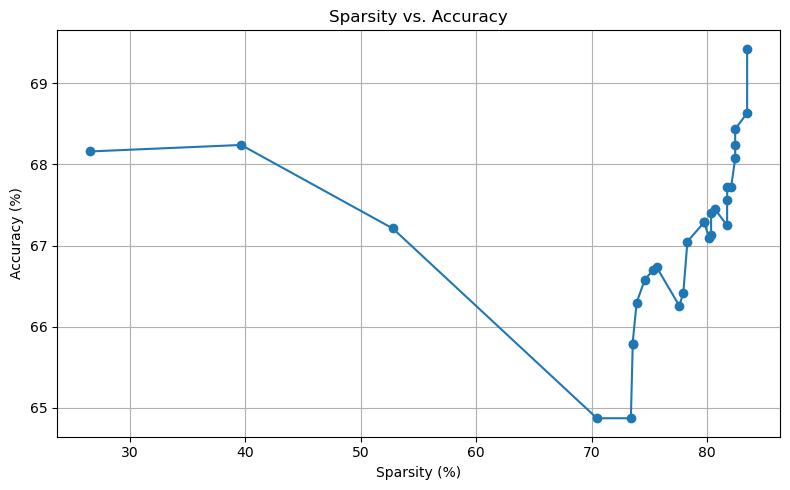

In [37]:
import matplotlib.pyplot as plt

weights_folder = r"C:\Users\nickc\OneDrive\Documents\CMU\Machine Learning With Large Datasets\Miniproject\model_weights"   # Folder with .pt files
sparsity_list = [26.54, 39.64, 52.78, 70.46, 73.40, 73.56]
accuracy_list = [68.16, 68.24, 67.21, 64.87, 64.87, 65.78]

def calculate_sparsity(model):
    total_params = 0
    zero_params = 0
    for param in model.parameters():
        total_params += param.numel()
        zero_params += torch.sum(param == 0).item()
    return 100 * zero_params / total_params

for file in sorted(os.listdir(weights_folder)):
    if file.endswith(".pt"):
        path = os.path.join(weights_folder, file)
        model = ConvNet().to(device)
        model.load_state_dict(torch.load(path, map_location=device))

        # Get accuracy
        _, acc = validate(model, val_loader, criterion, device)

        # Get sparsity
        sparsity = calculate_sparsity(model)

        print(f"{file}: Acc={acc:.2f}% | Sparsity={sparsity:.2f}%")

        accuracy_list.append(acc)
        sparsity_list.append(sparsity)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sparsity_list, accuracy_list, marker='o')
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Sparsity vs. Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()
